In [5]:
# Win Probability Analysis

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np

In [7]:
df = pd.read_csv('./esports_player_performance_tournament_analytics.csv')

In [8]:
# Win probability by team
team_winprob = df.groupby('team_name')['win_probability'].mean().sort_values(ascending=False)

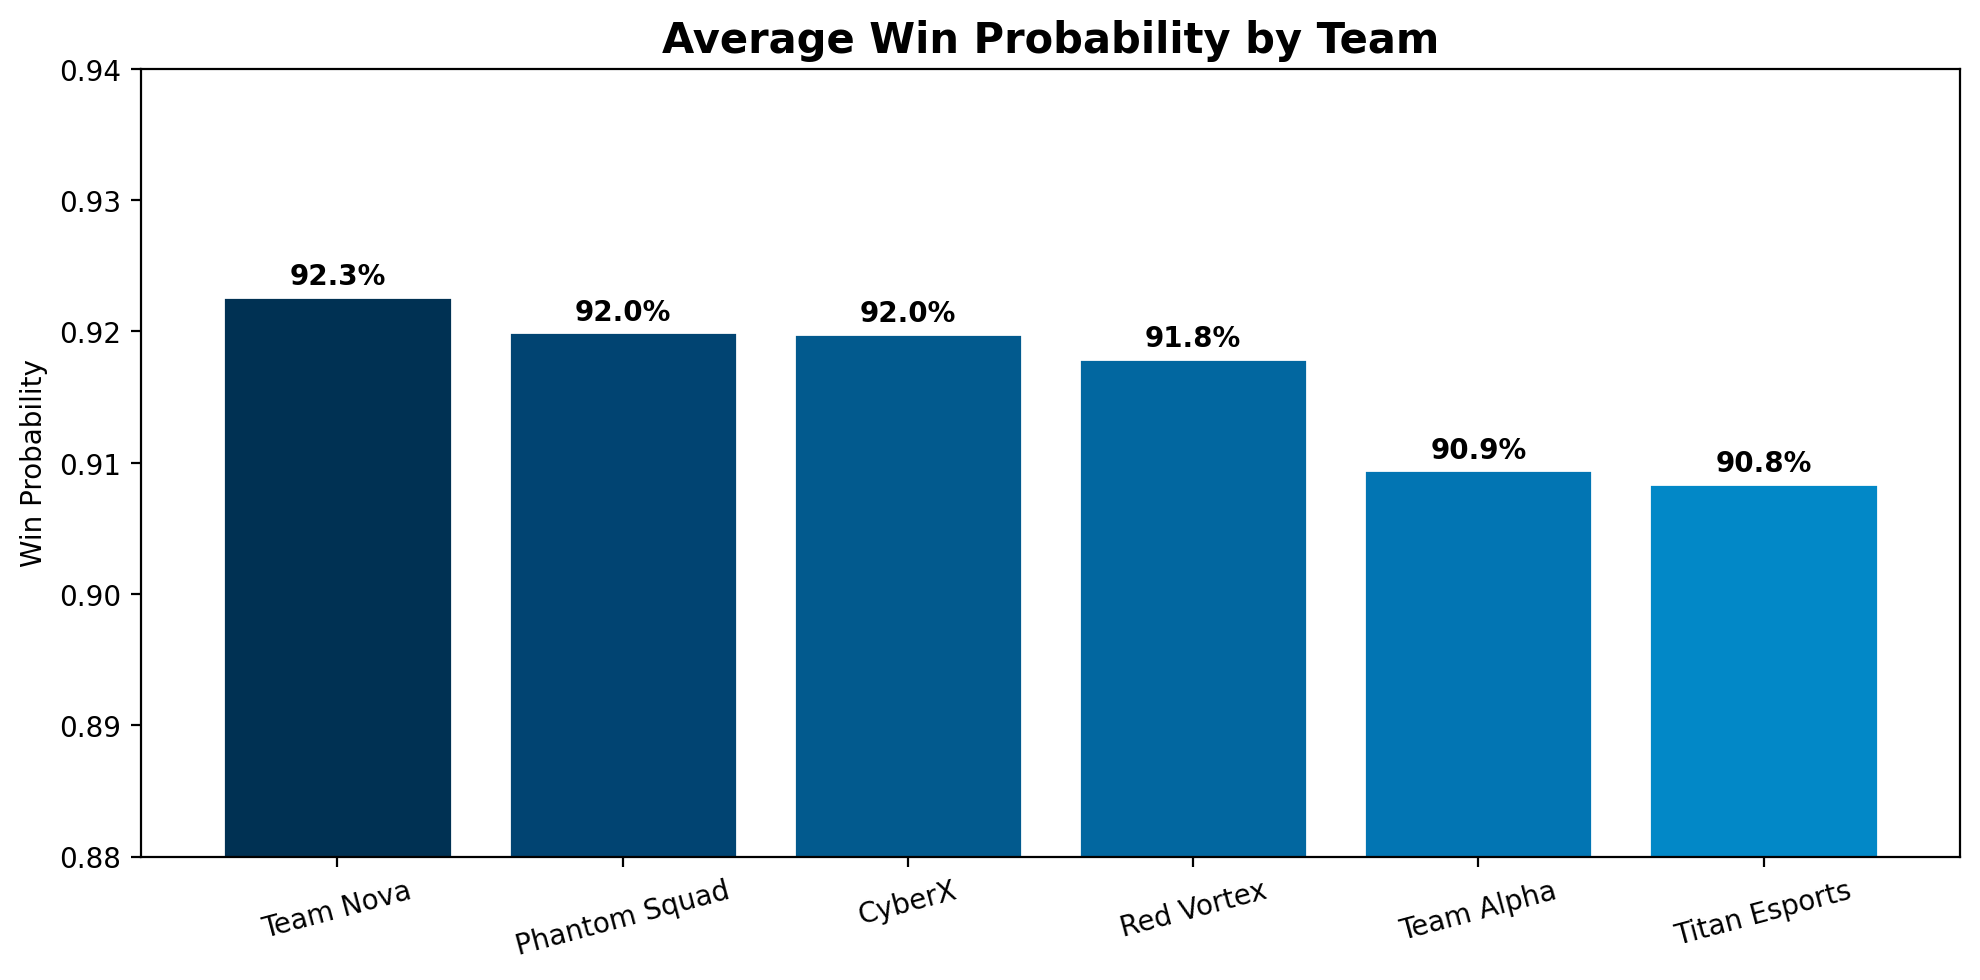

In [28]:
plt.figure(figsize=(10, 5))
colors = ['#003153', '#014472', '#025A8E', '#0267A0', '#0275B3', '#0288C7']
bars = plt.bar(team_winprob.index, team_winprob.values, color=colors, edgecolor='white')
plt.title('Average Win Probability by Team', fontsize=15, fontweight='bold')
plt.ylabel('Win Probability')
plt.ylim(0.88, 0.94)
plt.xticks(rotation=15)
for bar, val in zip(bars, team_winprob.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.0005,
             f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('win_probability_by_team.png', dpi=150)
plt.show()

In [10]:
# Correlations with win probability
num_cols = ['kills','assists','deaths','accuracy_percent',
            'reaction_time_ms','fatigue_index','performance_score','win_probability']
corr_with_win = df[num_cols].corr()['win_probability'].drop('win_probability').sort_values(ascending=False)
print('\nCorrelation with Win Probability:')
print(corr_with_win.round(3))


Correlation with Win Probability:
performance_score    0.639
kills                0.482
accuracy_percent     0.269
assists              0.182
reaction_time_ms    -0.018
deaths              -0.169
fatigue_index       -0.219
Name: win_probability, dtype: float64


In [11]:
# Consistentcy analysis 

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [13]:
df = pd.read_csv('./esports_player_performance_tournament_analytics.csv')

In [14]:
# Team consistency (std dev of performance score)
consistency = df.groupby('team_name')['performance_score'].agg(['mean','std','min','max'])
consistency.columns = ['Mean Score','Std Dev','Min','Max']
consistency = consistency.sort_values('Std Dev')
print('Team Consistency Rankings:')
print(consistency.round(2))

Team Consistency Rankings:
               Mean Score  Std Dev    Min    Max
team_name                                       
Titan Esports       44.38    10.04  16.58  71.53
Team Nova           45.85    10.06  17.27  77.02
Phantom Squad       45.69    10.13  20.41  75.16
Team Alpha          45.31    10.25  16.84  76.59
Red Vortex          45.09    10.73  17.64  87.36
CyberX              45.51    10.73  17.32  75.77


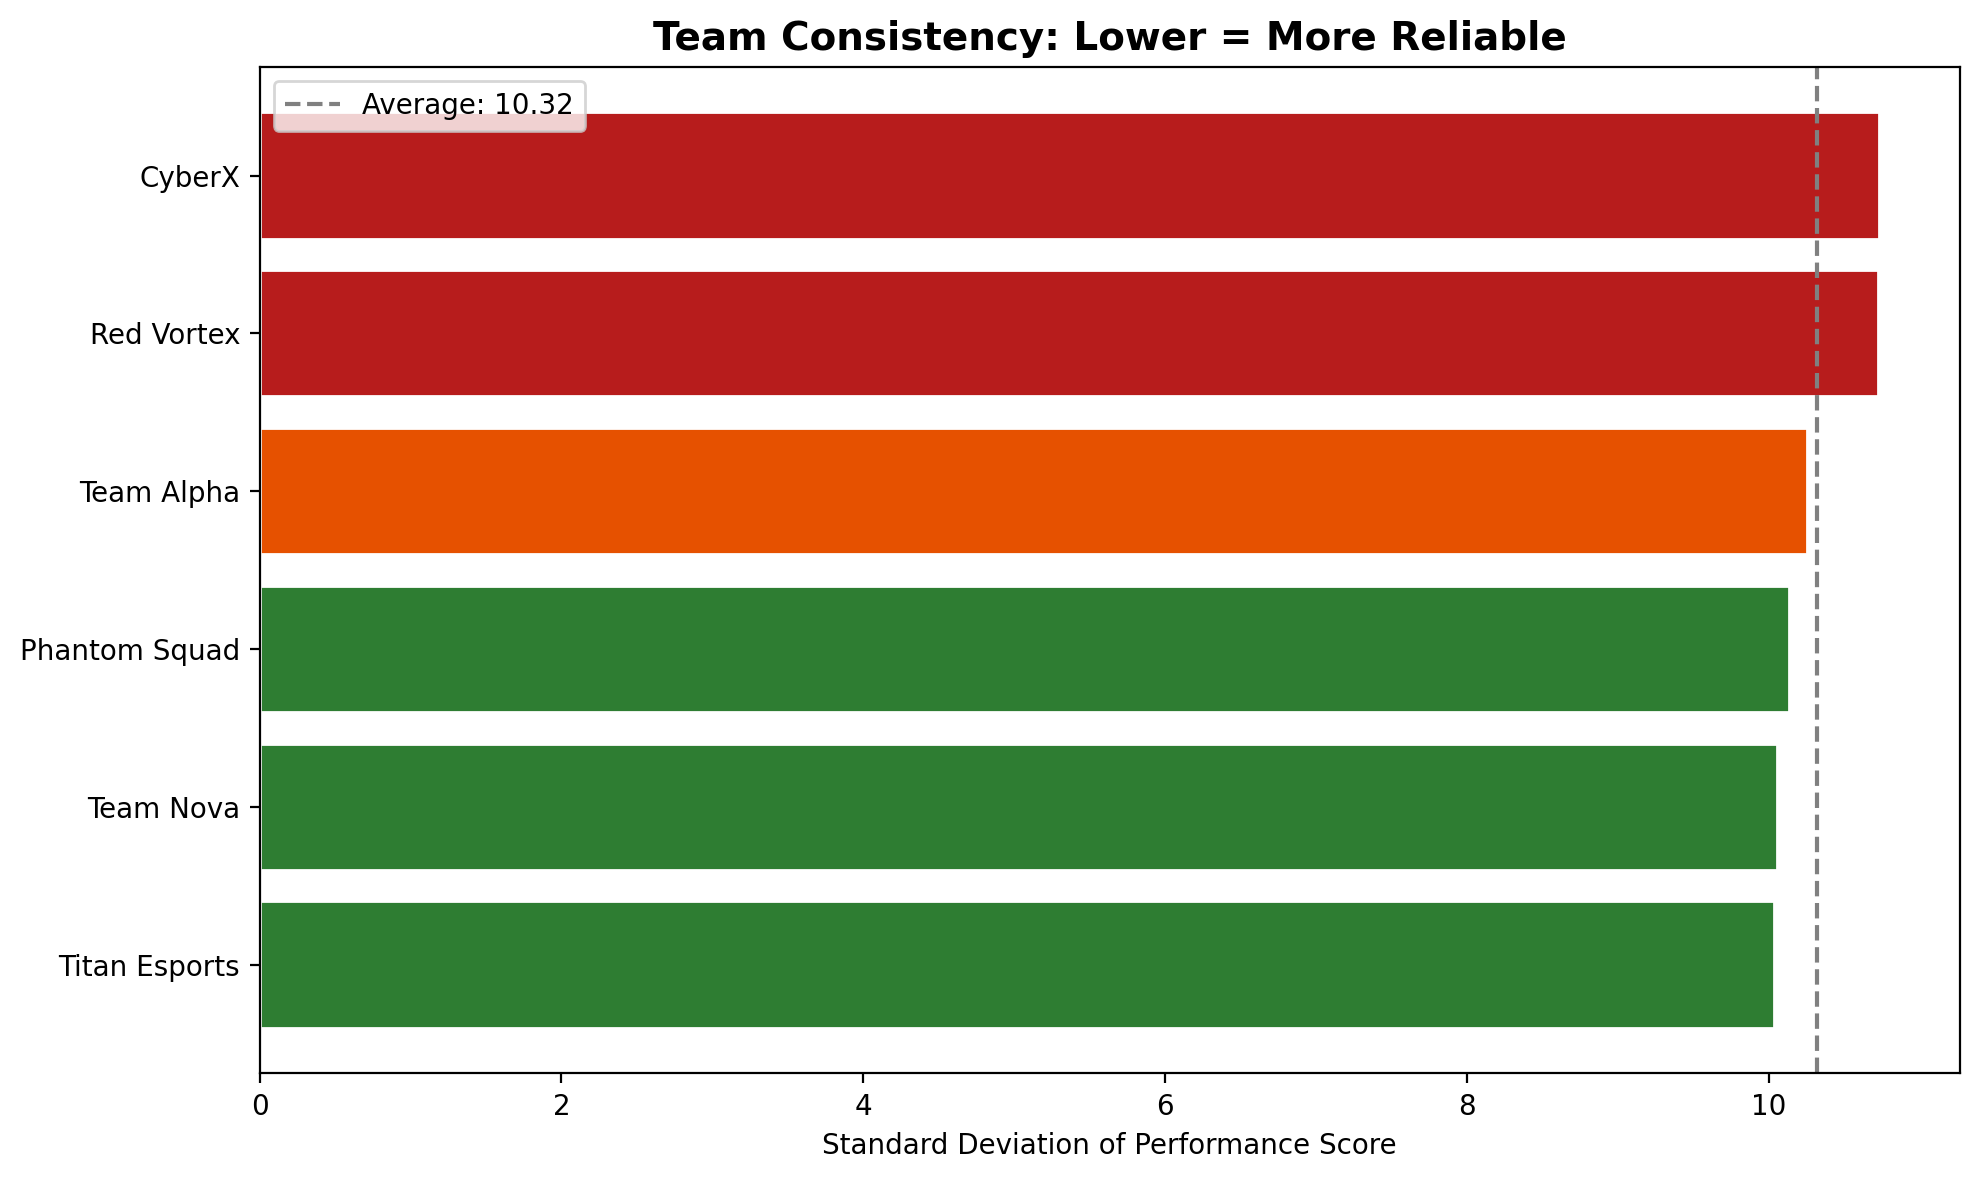

In [15]:
# Plot: Mean with error bars showing ± std dev
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2E7D32' if s < 10.2 else '#E65100' if s < 10.5 else '#B71C1C'
          for s in consistency['Std Dev']]
ax.barh(consistency.index, consistency['Std Dev'], color=colors, edgecolor='white')
ax.set_xlabel('Standard Deviation of Performance Score')
ax.set_title('Team Consistency: Lower = More Reliable', fontsize=14, fontweight='bold')
ax.axvline(consistency['Std Dev'].mean(), color='gray', linestyle='--',
           label=f'Average: {consistency["Std Dev"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('team_consistency.png', dpi=150)
plt.show()

In [16]:
# Coefficient of Variation (normalized consistency) 
consistency['CV'] = (consistency['Std Dev'] / consistency['Mean Score']).round(4)
print('\nCoefficient of Variation (lower = more consistent):')
print(consistency[['Mean Score','Std Dev','CV']].sort_values('CV'))


Coefficient of Variation (lower = more consistent):
               Mean Score    Std Dev      CV
team_name                                   
Team Nova       45.847420  10.056635  0.2194
Phantom Squad   45.694805  10.132415  0.2217
Titan Esports   44.383951  10.035743  0.2261
Team Alpha      45.308030  10.250780  0.2262
CyberX          45.506786  10.729750  0.2358
Red Vortex      45.092905  10.725288  0.2378


In [17]:
# Fatigue Analysis

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('./esports_player_performance_tournament_analytics.csv')

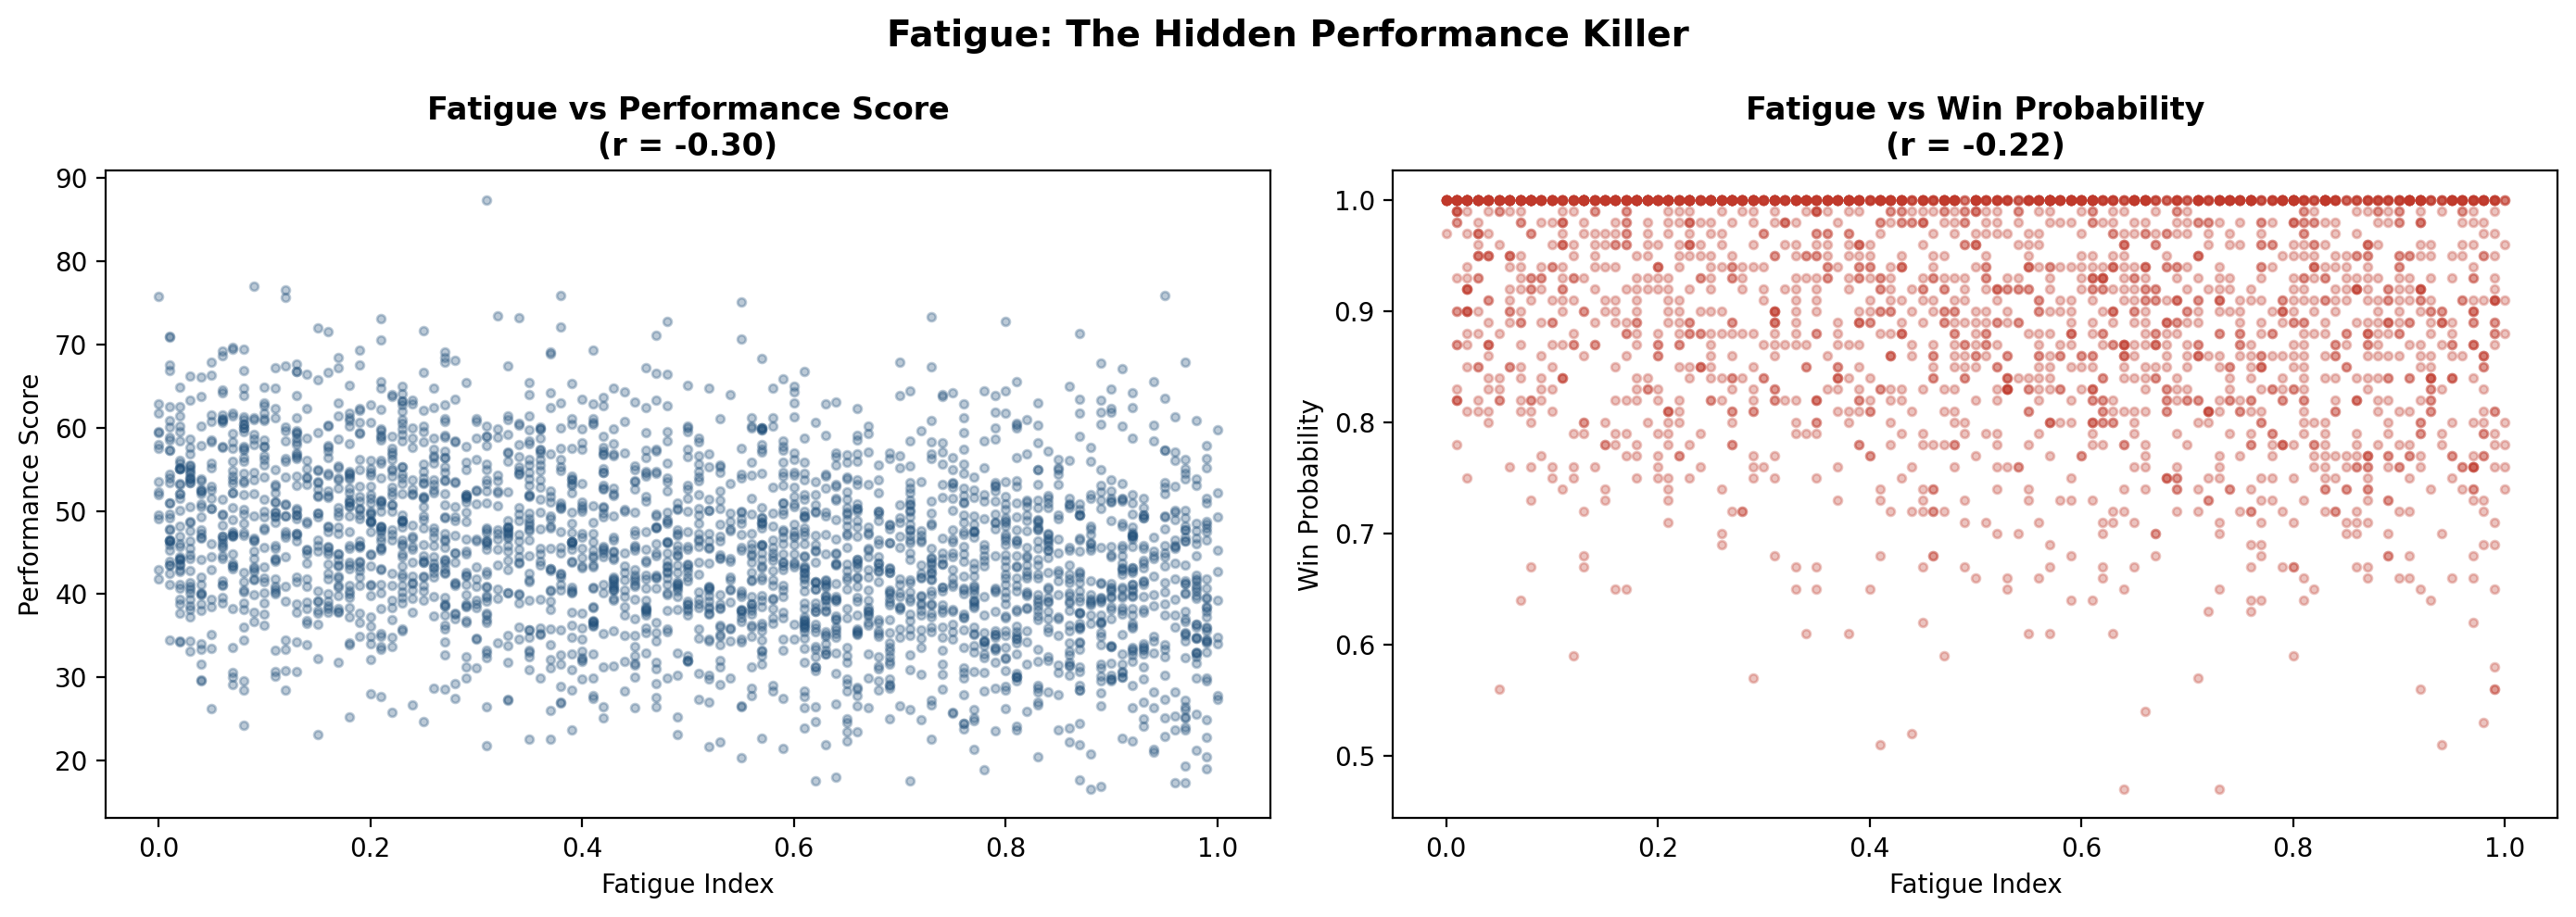

In [20]:
# Fatigue vs Performance Score scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['fatigue_index'], df['performance_score'],
                alpha=0.3, color='#1F4E79', s=10)
axes[0].set_xlabel('Fatigue Index')
axes[0].set_ylabel('Performance Score')
axes[0].set_title('Fatigue vs Performance Score\n(r = -0.30)', fontweight='bold')

axes[1].scatter(df['fatigue_index'], df['win_probability'],
                alpha=0.3, color='#C0392B', s=10)
axes[1].set_xlabel('Fatigue Index')
axes[1].set_ylabel('Win Probability')
axes[1].set_title('Fatigue vs Win Probability\n(r = -0.22)', fontweight='bold')

plt.suptitle('Fatigue: The Hidden Performance Killer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fatigue_impact.png', dpi=150)
plt.show()

In [21]:
# Fatigue correlation summary
cols = ['fatigue_index','performance_score','win_probability','kills','accuracy_percent']
print('Fatigue correlations:')
print(df[cols].corr()['fatigue_index'].drop('fatigue_index').sort_values())

Fatigue correlations:
performance_score   -0.301554
win_probability     -0.219400
accuracy_percent    -0.043177
kills                0.001381
Name: fatigue_index, dtype: float64


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv('esports_player_performance_tournament_analytics.csv')

Performance by Role:
                mean    std
player_role                
IGL            45.83  10.21
Entry Fragger  45.57  10.98
Sniper         45.09  10.17
Flex           45.01   9.99
Support        44.99  10.27


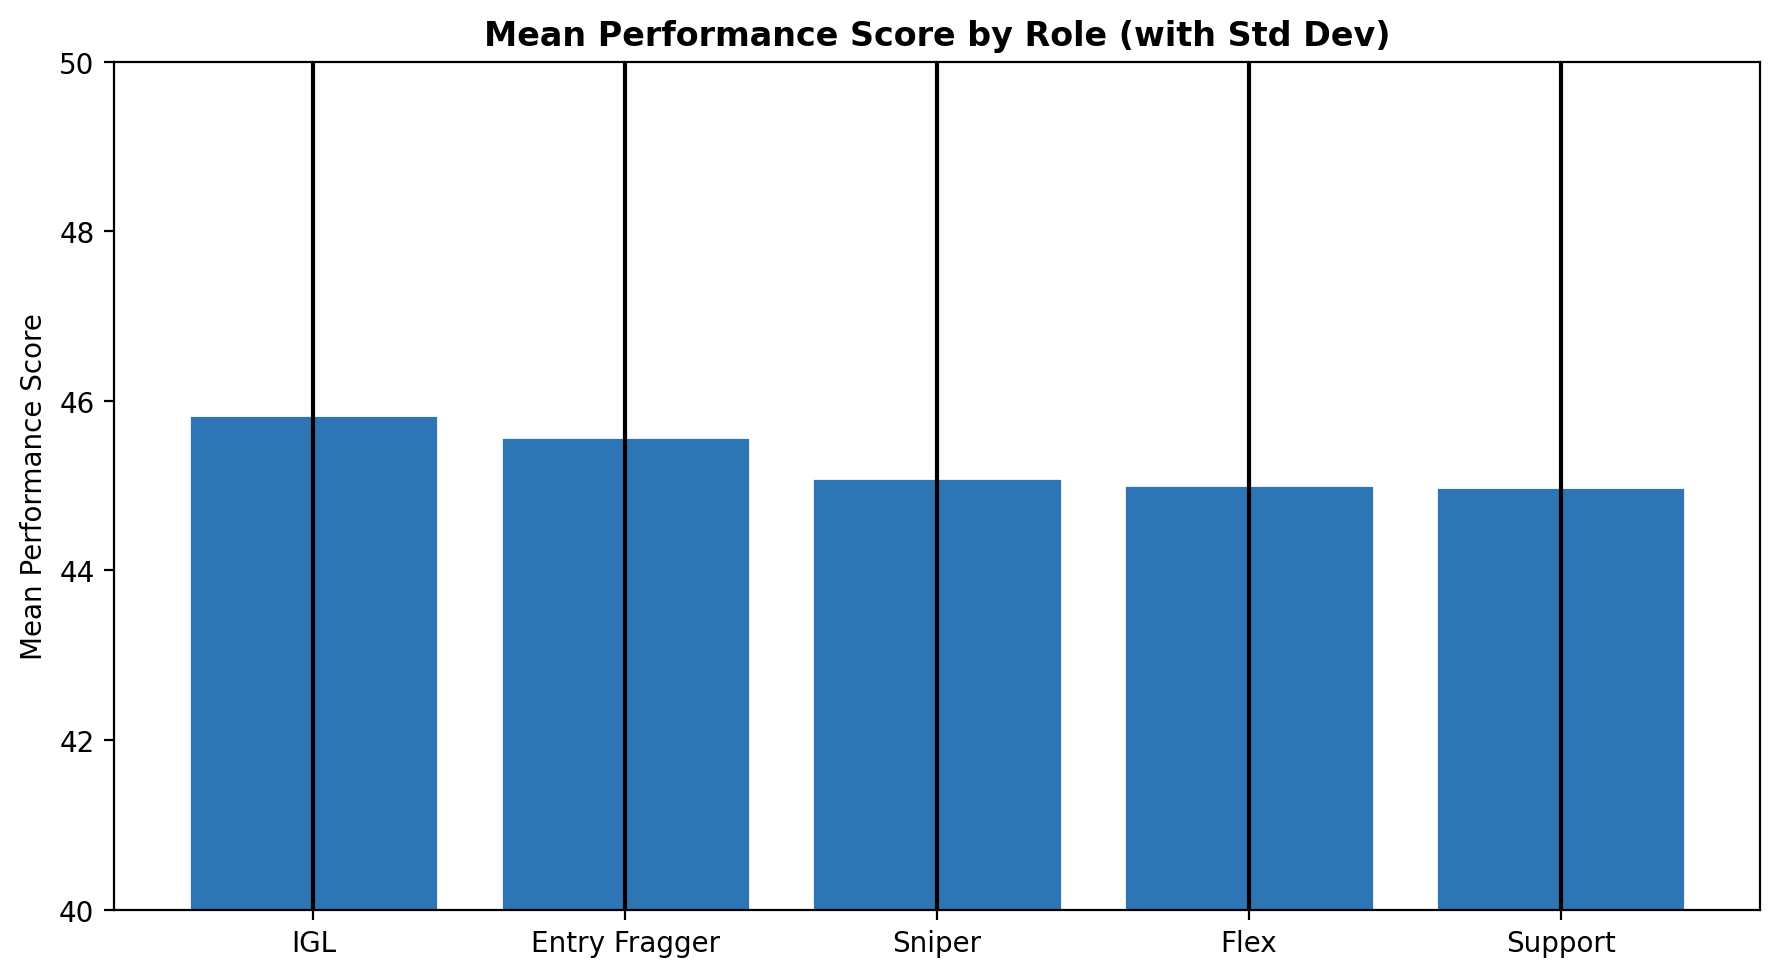

In [24]:
# Performance by role 
role_perf = df.groupby('player_role')['performance_score'].agg(['mean','std'])
role_perf = role_perf.sort_values('mean', ascending=False)
print('Performance by Role:')
print(role_perf.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(role_perf.index, role_perf['mean'], yerr=role_perf['std'],
       color='#2E75B6', capsize=5, edgecolor='white')
ax.set_title('Mean Performance Score by Role (with Std Dev)', fontweight='bold')
ax.set_ylabel('Mean Performance Score')
ax.set_ylim(40, 50)
plt.tight_layout()
plt.savefig('role_performance.png', dpi=150)
plt.show()